# Customer Churn Prediction and Retention Analysis Using Machine

## Jiahua Liu & Yifan Yu
## Deadline Dodgers

## 1. Executive Summary

**1.1 Decisions to be impacted**

This project supports three key managerial decisions in customer retention management:

(1) Precision Targeting Decision

The predictive model ranks customers by churn probability. Applying Pareto Analysis, we focus on the small proportion of high-risk customers who account for the majority of potential revenue loss. By targeting only this critical segment, the company can allocate retention resources more efficiently, maximize ROI, and avoid unnecessary incentives for low-risk customers.

(2) Intervention Timing Decision

Moving beyond simple contract tracking, we implement a lifecycle-value segmentation approach that integrates tenure, usage intensity, and spending. This allows for strategic intervention timing—targeting high-value customers at their most vulnerable lifecycle stages to maximize both retention impact and resource efficiency.

(3) Risk Threshold Decision

The model enables the establishment of an economically optimized risk threshold for intervention. Instead of relying on arbitrary percentages or intuition, retention actions are guided by cost-sensitive evaluation and quantified churn risk.

**1.2 Business value**

The primary business value of this project lies in revenue preservation and cost optimization.

• Revenue Protection:

By proactively identifying customers at risk of churn, the company can prevent revenue loss and maximize Customer Lifetime Value (CLV).

• Marketing ROI Improvement:

Targeted interventions reduce unnecessary spending on low-risk customers, increasing the return on investment of retention campaigns.

• Strategic Resource Allocation:

Rather than reacting to churn after it occurs, this model enables proactive strategy, shifting retention management from a reactive cost center to a value-generating system.

• Long-Term Competitive Stability:

Reducing customer attrition strengthens market position and stabilizes recurring revenue streams in a saturated telecom market.

**1.3 Data assets**

The project utilizes the Telco Customer Churn dataset, publicly available on Kaggle and originally sourced from IBM. The dataset contains 7,043 customer records and provides a comprehensive view of customer profiles across three major dimensions: demographic characteristics (e.g., gender and senior status), service subscription details (e.g., internet type and streaming services), and account and financial information (e.g., contract type and monthly charges). This multi-dimensional structure allows for a holistic understanding of customer behavior within a subscription-based telecom environment.
The integration of behavioral and financial variables enables the identification of key churn drivers, the estimation of individual-level churn probability, and the simulation of cost-benefit scenarios for targeted retention strategies. Because the dataset is structured, clean, and clearly labeled with a binary churn outcome, it is well suited for supervised machine learning modeling and decision-oriented business evaluation.


## 2. Data Preprocessing

In [2]:
#input dataset
import pandas as pd

df = pd.read_csv("Telco_customer_churn.csv")

## 2.1 Data Description -- summary of datasets and visualizations of input data

**2.1.1 Dataset Overview**

The dataset contains 7,043 customer observations and 33 variables. Among these variables, churn outcome information is recorded in two forms: categorical variable (Churn Label: Yes/No) and its numerical representation (Churn Value: 1 = churn/Yes, 0 = retained/No).  

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.shape

(7043, 33)

These variables capture whether a customer discontinued service in the previous month. The remaining variables serve as explanatory features and can be categorized by data type and business domain, as summarized in Table 1 and Table 2. This structure provides a comprehensive representation of customer demographics, service usage, and financial characteristics.

In [5]:
#table 1.Variable Classification by Data Type

# identify variables
numerical_vars = df.select_dtypes(include=['number']).columns.tolist()
categorical_vars = df.select_dtypes(exclude=['number']).columns.tolist()

# combine into table
table_type = pd.DataFrame({
    "Data_Type": ["Categorical", "Numerical"],
    "Variables": [
        ", ".join(categorical_vars),
        ", ".join(numerical_vars)
    ]
})

# display
pd.set_option('display.max_colwidth', None)
table_type.style.set_properties(**{'text-align': 'left'})

,Data_Type,Variables
0,Categorical,"CustomerID, Country, State, City, Lat Long, Gender, Senior Citizen, Partner, Dependents, Phone Service, Multiple Lines, Internet Service, Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies, Contract, Paperless Billing, Payment Method, Total Charges, Churn Label, Churn Reason"
1,Numerical,"Count, Zip Code, Latitude, Longitude, Tenure Months, Monthly Charges, Churn Value, Churn Score, CLTV"


In [6]:
#table 2. Variable Classification by Business Domain
# define variable groups
demographic_vars = ["Gender","SeniorCitizen","Partner","Dependents"]

service_vars = [
    "PhoneService","MultipleLines","InternetService",
    "OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies"
]

account_fin_vars = [
    "TenureMonths","Contract","PaperlessBilling",
    "PaymentMethod","MonthlyCharges","TotalCharges","CLTV"
]

# create table
table_domain = pd.DataFrame({
    "Category": [
        "Demographic Characteristics",
        "Service Subscription Details",
        "Account and Financial Information"
    ],
    "Variables": [
        ", ".join(demographic_vars),
        ", ".join(service_vars),
        ", ".join(account_fin_vars)
    ]
})

# display
pd.set_option('display.max_colwidth', None)
table_domain.style.set_properties(**{'text-align': 'left'})

,Category,Variables
0,Demographic Characteristics,"Gender, SeniorCitizen, Partner, Dependents"
1,Service Subscription Details,"PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies"
2,Account and Financial Information,"TenureMonths, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, CLTV"


**2.1.2 Target Variable Distribution -- Churn Value**

As shown in Table 3, the distribution of the target variable reveals a moderate class imbalance, with churn customers representing approximately 26.5% of the total sample. While not severely skewed, this imbalance warrants careful model evaluation using class-sensitive performance metrics.

In [7]:
target_counts = df["Churn Value"].value_counts(dropna=False).sort_index()
target_props = df["Churn Value"].value_counts(normalize=True, dropna=False).sort_index()

target_dist = pd.DataFrame({
    "ChurnValue": target_counts.index,
    "Count": target_counts.values,
    "Proportion": target_props.values
})

target_dist

,ChurnValue,Count,Proportion
0,0,5174,0.73463
1,1,1869,0.26537


**2.1.3 Numerical Feature Analysis**

The numerical variables display varying levels of dispersion and scale. Notably, Total Charges and CLTV exhibit substantially larger ranges compared to other variables, suggesting potential right-skewness and scale differences. Such disparities in magnitude may require normalization or standardization prior to modeling. Additionally, the broad distribution of Tenure Months indicates heterogeneity in customer retention behavior, which may be strongly associated with churn outcomes. (Table 4)

In [8]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# numerical feature analysis
num_vars_clean = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Score",
    "CLTV"
]

desc_table = df[num_vars_clean].agg(["mean", "std", "min", "max"]).T.reset_index()
desc_table.columns = ["Variable", "Mean", "SD", "Min", "Max"]

desc_table = desc_table.round(2)

desc_table

,Variable,Mean,SD,Min,Max
0,Tenure Months,32.37,24.56,0.00,72.00
1,Monthly Charges,64.76,30.09,18.25,118.75
2,Total Charges,2283.30,2266.77,18.80,8684.80
3,Churn Score,58.70,21.53,5.00,100.00
4,CLTV,4400.30,1183.06,2003.00,6500.00


**2.1.4 Categorical Feature Analysis**

The dataset contains several categorical variables describing customer demographics, services, and billing characteristics. Examples include Gender, Partner, Dependents, Contract Type, Internet Service, and Payment Method. While many categorical variables are available, this analysis focuses on three key variables: Contract Type, Internet Service, and Payment Method.

These variables were selected because they are directly related to customer service structure and billing behavior, which are known to strongly influence customer churn in telecommunications services. Contract type reflects the level of commitment between the customer and the company, internet service represents the type of service provided, and payment method describes how customers interact with the billing system. These factors are often associated with customer satisfaction and switching behavior.


The visualizations show that contract type has a clear relationship with churn behavior. Customers with month-to-month contracts exhibit significantly higher churn rates compared to customers with one-year or two-year contracts, indicating that longer contractual commitments may help reduce churn.

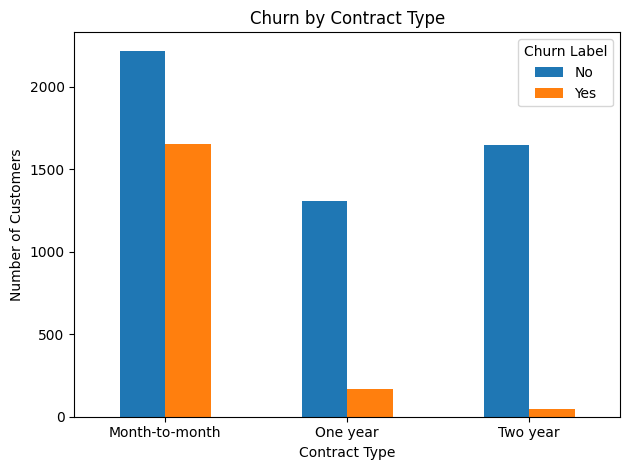

In [9]:
#=================Contract vs Churn==================
import pandas as pd
import matplotlib.pyplot as plt
df_clean = df.copy()
df_clean["Total Charges"] = pd.to_numeric(df_clean["Total Charges"], errors="coerce")
contract_churn = pd.crosstab(df_clean["Contract"], df_clean["Churn Label"])

contract_churn.plot(kind="bar")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.tight_layout()
plt.show()


For internet service, customers using fiber optic services appear to have a higher churn proportion compared to DSL or customers without internet service, which may suggest differences in service cost, expectations, or service quality.


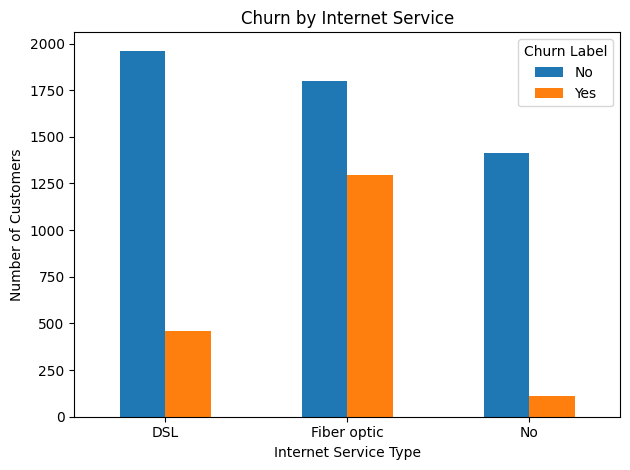

In [10]:
#=================Internet Service vs Churn==================
internet_churn = pd.crosstab(df_clean["Internet Service"], df_clean["Churn Label"])

internet_churn.plot(kind="bar")
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn Label")
plt.tight_layout()
plt.show()

In terms of payment method, customers who use electronic check payments show noticeably higher churn rates compared to those using automatic bank transfer or credit card payments, suggesting that automated payment methods may be associated with higher customer retention.

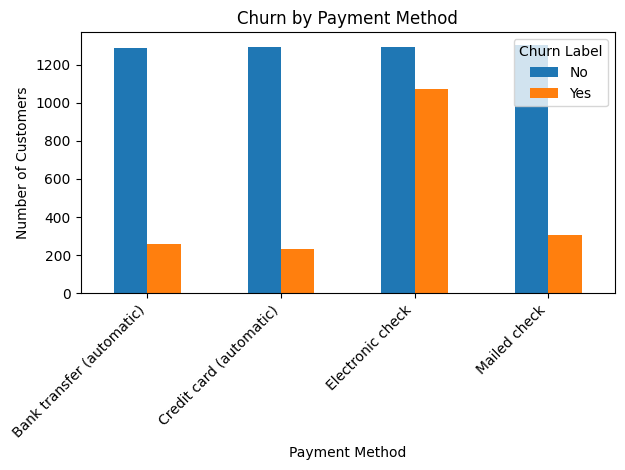

In [11]:
#=================Payment Method vs Churn=================
payment_churn = pd.crosstab(df_clean["Payment Method"], df_clean["Churn Label"])

payment_churn.plot(kind="bar")
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Churn Label")
plt.tight_layout()
plt.show()

Overall, these three categorical variables provide meaningful insights into customer churn behavior and are therefore selected as representative features for categorical feature analysis.

**2.1.5 Bivariate Relationships with Churn**

Variable Selection
Although the dataset contains many variables, not all of them are suitable for analyzing the relationship with customer churn. Several variables such as CustomerID, Country, State, City, Zip Code, Latitude, and Longitude mainly serve as identifiers or geographic information and do not directly reflect customer behavior or service usage. Therefore, they are unlikely to provide meaningful insights into churn behavior.

Additionally, some variables such as Count contain no variation across observations, while Churn Reason is only recorded for customers who have already churned, making it unsuitable as a predictor for churn analysis.

Based on the earlier univariate analysis, a subset of variables that are more closely related to customer engagement, service usage, and billing characteristics was selected for further investigation. These variables include **Tenure Months, Monthly Charges, Total Charges, Contract Type, Internet Service, and Payment Method**, which are commonly considered key factors influencing customer retention in telecommunications services.


**Numerical Variables vs Churn**

**a. Tenure Months vs Churn**

The boxplot shows a clear difference in tenure between churned and non-churned customers. Customers who did not churn generally have longer tenure periods, while customers who churned tend to have much shorter tenure durations. The median tenure for churned customers is significantly lower than that of non-churned customers. This suggests that newer customers are more likely to churn, indicating that customer retention strategies may be particularly important during the early stages of the customer lifecycle.


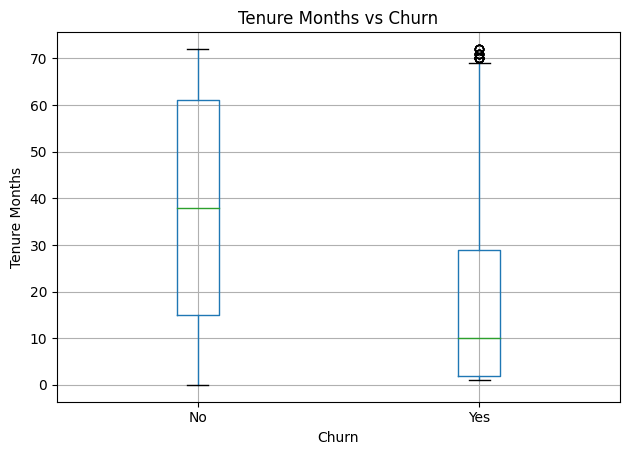

In [12]:
# Tenure Months vs Churn
df_clean.boxplot(column="Tenure Months", by="Churn Label")
plt.title("Tenure Months vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure Months")
plt.tight_layout()
plt.show()

**b. Monthly Charges vs Churn**

The distribution of monthly charges indicates that customers who churn tend to have higher monthly charges on average compared to those who remain with the service. The median monthly charge for churned customers is noticeably higher. This suggests that higher service costs may increase the likelihood of churn, possibly because customers perceive the service as less cost-effective compared to alternatives.


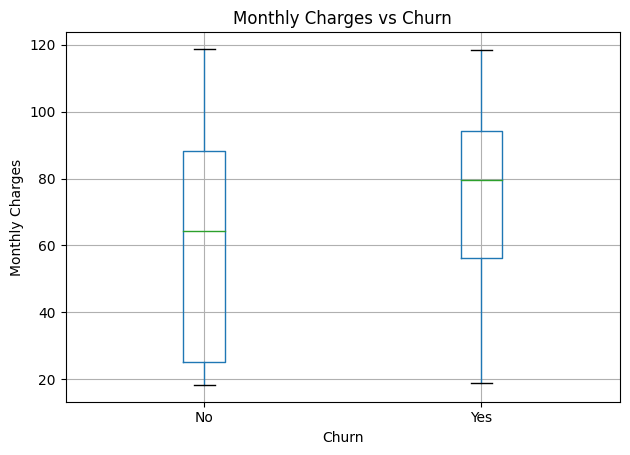

In [13]:
# Monthly Charges vs Churn
df_clean.boxplot(column="Monthly Charges", by="Churn Label")
plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

**c. Total Charges vs Churn**

The total charges distribution shows that non-churned customers typically accumulate higher total charges over time, which is expected since they tend to remain with the service for longer periods. In contrast, churned customers usually have lower total charges, reflecting their shorter tenure with the company. This pattern further supports the observation that customers who stay longer contribute more total revenue and are less likely to churn.


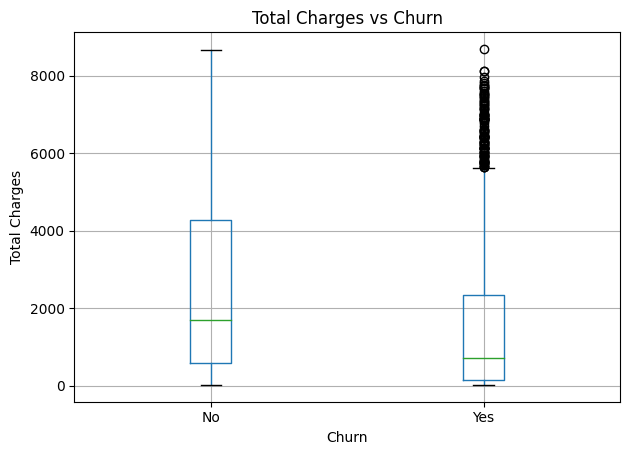

In [14]:
# Total Charges vs Churn
df_clean.boxplot(column="Total Charges", by="Churn Label")
plt.title("Total Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.tight_layout()
plt.show()

**Categorical Variables vs Churn**

**a. Contract Type vs Churn Rate**

The analysis of contract type reveals a strong relationship with churn behavior. Customers with month-to-month contracts exhibit the highest churn rate, significantly higher than those with one-year or two-year contracts. In contrast, customers with longer-term contracts have much lower churn rates. This suggests that longer contractual commitments help improve customer retention, as customers are less likely to leave before their contract period ends.


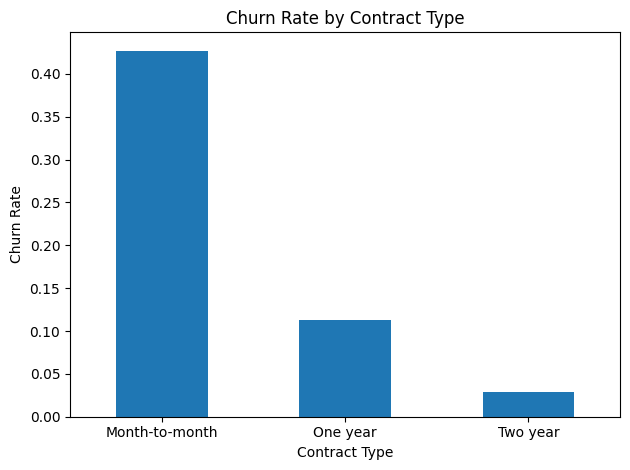

In [15]:
# Contract vs Churn Rate
contract_rate = pd.crosstab(df_clean["Contract"], df_clean["Churn Label"], normalize="index")

contract_rate.iloc[:, 1].plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**b. Internet Service vs Churn Rate**

Among the different internet service types, customers using fiber optic services show the highest churn rate, while DSL users have a moderate churn rate and customers without internet service show the lowest churn rate. This pattern may indicate differences in service expectations, pricing, or service quality, which could influence customer satisfaction and retention.


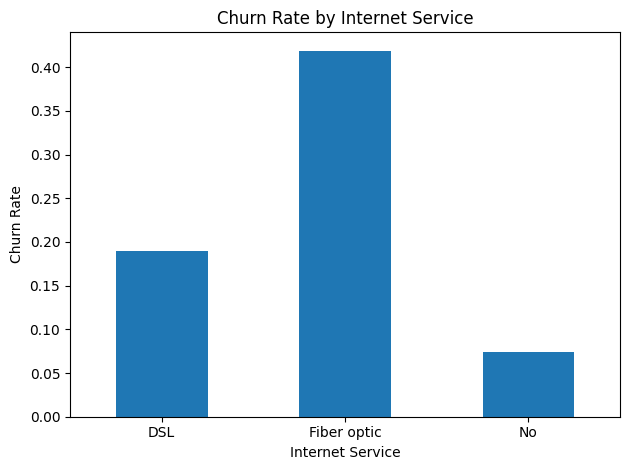

In [16]:
# Internet Service vs Churn Rate
internet_rate = pd.crosstab(df_clean["Internet Service"], df_clean["Churn Label"], normalize="index")

internet_rate.iloc[:, 1].plot(kind="bar")
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**c. Payment Method vs Churn Rate**
    
The churn rate also varies across payment methods. Customers who pay using electronic check exhibit the highest churn rate, whereas those using automatic payment methods such as bank transfer or credit card tend to have lower churn rates. This suggests that automatic payment methods may be associated with stronger customer commitment and more stable service usage.


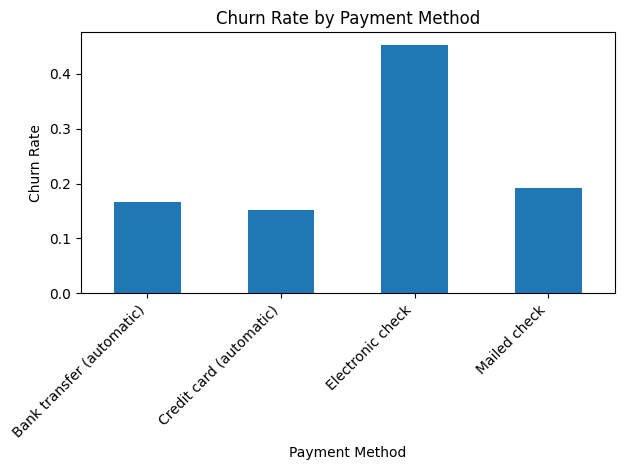

In [17]:
# Payment Method vs Churn Rate
payment_rate = pd.crosstab(df_clean["Payment Method"], df_clean["Churn Label"], normalize="index")

payment_rate.iloc[:, 1].plot(kind="bar")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Overall, the bivariate analysis indicates that both customer tenure and billing characteristics are strongly associated with churn behavior. Customers who are newer, pay higher monthly charges, use month-to-month contracts, subscribe to fiber optic services, or use electronic check payment methods appear to have a higher likelihood of churning. These findings provide useful insights for identifying high-risk customers and developing targeted retention strategies.


## 2.2 Introduce the data cleaning metrics you used in the process and outlier detection

**2.2.1 Identify outlier and missing value**

**a. Outlier Detection**

Outlier detection was conducted on the *Total Charges* variable. Although the dataset contains multiple variables, many of them are categorical (e.g., Gender, Contract, Internet Service), for which outlier detection is not applicable. Among the numerical variables, *Total Charges* was selected because it represents the total amount paid by a customer over their service period, making it an important indicator of customer spending behavior. In addition, this variable typically exhibits a wider range compared to other numerical features and is therefore more likely to contain extreme values.

To identify potential outliers, three methods were applied: the IQR method, Z-score method, and boxplot visualization. Based on the Python analysis, no significant outliers were detected in the *Total Charges* variable using either the IQR or Z-score methods. This result is further supported by the boxplot, which does not display any clear extreme observations.

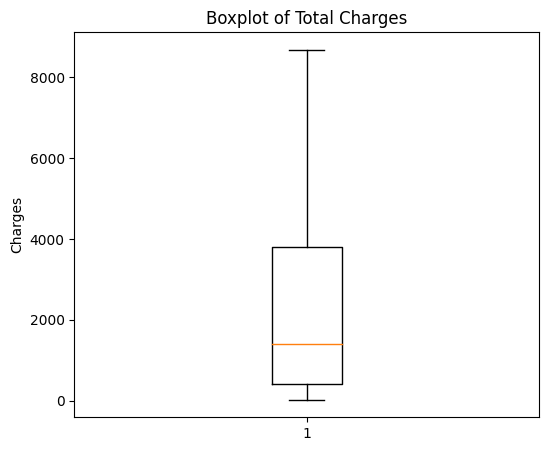

Q1: 401.4
Q3: 3794.975
IQR: 3393.575
Lower bound: -4688.9625
Upper bound: 8885.3375
Total Charges outlier count: 0


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tc = pd.to_numeric(df["Total Charges"], errors="coerce")
tc_clean = tc.dropna()

#======================= IQR Method =======================

# Boxplot
plt.figure(figsize=(6, 5))
plt.boxplot(tc_clean)
plt.title("Boxplot of Total Charges")
plt.ylabel("Charges")
plt.show()

df["Total_Charges_log"] = np.log(tc + 1)

Q1 = tc_clean.quantile(0.25, interpolation='midpoint')
Q3 = tc_clean.quantile(0.75, interpolation='midpoint')

IQR_value = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR_value
upper_bound = Q3 + 1.5 * IQR_value

outliers_TotalCharges = tc_clean[
    (tc_clean < lower_bound) | (tc_clean > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR_value)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Total Charges outlier count:", len(outliers_TotalCharges))

In [19]:
#=======================Z-score Method=======================
x = df["Total Charges"]
x = pd.to_numeric(df["Total Charges"], errors='coerce')
z_scores = (x - x.mean()) / x.std()

outliers_z = x[z_scores.abs() > 3]

print("Z-score outliers:", len(outliers_z.dropna()))

Z-score outliers: 0


In [20]:
#=======================Boxplot Method=======================
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors='coerce')
Q1_box = df["Total Charges"].quantile(0.25)
Q3_box = df["Total Charges"].quantile(0.75)
IQR_box = Q3_box - Q1_box

lower_box = Q1_box - 1.5 * IQR_box
upper_box = Q3_box + 1.5 * IQR_box

outliers_box = df["Total Charges"][
    (df["Total Charges"] < lower_box) | (df["Total Charges"] > upper_box)
]

print("Boxplot outliers:", len(outliers_box.dropna()))

Boxplot outliers: 0


The absence of detected outliers suggests that the distribution of *Total Charges* is relatively well-behaved, and high values observed in the dataset likely reflect genuine customer spending patterns rather than data errors. Therefore, no observations were removed, and the variable was retained in its original form for subsequent analysis.

**multivariance outlier detection**

Multivariate outlier detection was conducted using Tenure Months, Monthly Charges, Total Charges, and CLTV, as these variables are continuous and jointly capture the core structure of customer behavior and value. The selection of these variables is grounded in both statistical and business considerations. From a statistical perspective, Mahalanobis distance requires continuous numerical variables in order to estimate the mean vector and covariance matrix, which makes categorical variables such as gender, contract type, and payment method unsuitable for this method. More importantly, these selected variables exhibit strong interdependence. Tenure and monthly charges together determine total charges, while all three contribute to the estimation of customer lifetime value. This interconnected structure allows the model to identify not only extreme values in individual variables, but also unusual combinations that deviate from the expected relationships among variables. In this sense, the analysis focuses on detecting abnormal patterns rather than isolated extreme observations. Using Mahalanobis distance, each observation’s distance from the multivariate center of the distribution was computed while accounting for correlations among variables.

In [21]:
import pandas as pd
import numpy as np
from scipy.stats import chi2
from sklearn.preprocessing import StandardScaler

cols = ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV"]
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

data = df[cols].dropna().copy()

#standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

mean_vec = np.mean(X_scaled, axis=0)
cov_matrix = np.cov(X_scaled, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

#calculate Mahalanobis distance
diff = X_scaled - mean_vec
md_squared = np.sum(diff @ inv_cov_matrix * diff, axis=1)
md = np.sqrt(md_squared)

threshold = np.sqrt(chi2.ppf(0.99, df=len(cols)))

#detect outlier
data["Mahalanobis_Distance"] = md
data["Outlier"] = data["Mahalanobis_Distance"] > threshold

result = df.loc[data.index].copy()
result["Mahalanobis_Distance"] = data["Mahalanobis_Distance"]
result["Outlier"] = data["Outlier"]

print("Threshold:", threshold)
print("Number of outliers:", result["Outlier"].sum())
print(result[result["Outlier"]].head())

result.to_excel("telco_multivariate_outliers.xlsx", index=False)

Threshold: 3.6437211935036444
Number of outliers: 8
      CustomerID  Count        Country       State           City  Zip Code  \
2565  5787-KXGIY      1  United States  California      Palo Alto     94303   
2611  2545-LXYVJ      1  United States  California    Suisun City     94585   
2812  4821-WQOYN      1  United States  California   Little River     95456   
3135  0404-AHASP      1  United States  California  Beverly Hills     90212   
3211  1927-QEWMY      1  United States  California        Arcadia     91007   

                    Lat Long   Latitude   Longitude  Gender  ...  \
2565   37.45809, -122.115398  37.458090 -122.115398    Male  ...   
2611  38.197907, -122.017258  38.197907 -122.017258    Male  ...   
2812   39.245911, -123.77214  39.245911 -123.772140  Female  ...   
3135  34.062095, -118.401508  34.062095 -118.401508    Male  ...   
3211  34.128284, -118.047732  34.128284 -118.047732  Female  ...   

     Monthly Charges Total Charges Churn Label  Churn Value Chur

A threshold was determined based on the chi-square distribution at the 99% confidence level, resulting in a cutoff value of 3.6437. Observations with a Mahalanobis distance exceeding this threshold were classified as multivariate outliers. The results show that only eight observations in the dataset were identified as outliers, indicating that the overall data distribution is relatively well-behaved and does not contain a large number of anomalous cases.

A closer examination of these outliers reveals a consistent and interpretable pattern. These customers tend to have very low monthly charges, approximately around 20, while simultaneously exhibiting relatively high total charges and CLTV values. This combination deviates from the general trend observed in the dataset, where higher total charges are typically associated with higher monthly spending. The presence of low monthly charges alongside substantial accumulated charges suggests that these customers have maintained their subscriptions over a long period of time, resulting in high total contributions despite their low spending intensity. Furthermore, all identified outliers are non-churn customers, indicating that they are highly stable and retained over time. From a business perspective, these outliers likely represent long-tenure customers on legacy low-cost plans. As they reflect meaningful customer behavior rather than data errors, they were retained for further analysis.

**b. Identify Missing Value**

A missing value analysis was conducted to evaluate the completeness of the dataset. The number and percentage of missing values were calculated for each variable.

The results indicate that most variables in the dataset do not contain missing values, suggesting that the dataset is largely complete. However, two variables contain missing observations: Total Charges and Churn Reason.

The variable Total Charges contains 11 missing values, accounting for approximately 0.16% of the dataset. This is a very small proportion and is likely due to newly subscribed customers whose total charges have not yet been accumulated. Since the number of missing observations is negligible, these records can be safely removed without significantly affecting the dataset.

In contrast, the variable Churn Reason contains 5,174 missing values, representing approximately 73.46% of the dataset. This occurs because the churn reason is only recorded for customers who have actually churned, while customers who remain with the company do not have an associated churn reason. Therefore, these missing values are structural missing values rather than data quality issues.


In [22]:
missing_summary = pd.DataFrame({
    "Variable": df.columns,
    "Missing_Count": df.isna().sum().values,
    "Missing_Percentage": (df.isna().sum().values / len(df)) * 100
})

missing_summary = missing_summary.round({"Missing_Percentage": 2})

missing_summary

,Variable,Missing_Count,Missing_Percentage
0,CustomerID,0,0.00
1,Count,0,0.00
2,Country,0,0.00
3,State,0,0.00
4,City,0,0.00
5,Zip Code,0,0.00
6,Lat Long,0,0.00
7,Latitude,0,0.00
8,Longitude,0,0.00
9,Gender,0,0.00


Overall, the dataset contains minimal missing values in key variables, and appropriate handling strategies will be applied to ensure data quality in subsequent analyses.

**2.2.2 Handle outlier and missing value**


**a. Outlier treatment**

Outlier detection using the IQR and Z-score methods did not identify any significant outliers in the *Total Charges* variable. This finding is consistent with the boxplot visualization, which does not display any clear extreme observations.

Although the variable exhibits a relatively wide range, the observed high values are likely to reflect genuine customer behavior, particularly for long-term or high-spending customers, rather than data errors. Given that *Total Charges* represents the cumulative amount paid over a customer's service period, larger values are expected and do not necessarily indicate anomalies.

Therefore, no outlier treatment was required, and all observations were retained in the dataset for subsequent analysis.


**b. missing value treatment**

To address these missing values, median imputation was applied. The median was chosen instead of the mean because the Total Charges variable is right-skewed and may contain relatively large values from long-term or high-spending customers. In such cases, the mean can be influenced by extreme values, while the median provides a more robust measure of central tendency.

By replacing the missing values with the median of the observed data, the integrity of the dataset is preserved without introducing significant bias. This approach ensures that the imputed values remain representative of the typical customer spending level while minimizing the impact of potential outliers.


In [23]:
df_clean = df.copy()

# Replace missing values in Total Charges with median
df_clean["Total Charges"] = df_clean["Total Charges"].fillna(
    df_clean["Total Charges"].median()
)

# Check missing values again
df_clean.isna().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
Total_Charges_log      11
dtype: int64

## 3. Data procession

**3.1 Data preparation**

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

y = df["Churn Value"].astype(int).copy()

drop_cols = [
    "Churn Value", "Churn Label", "Churn Score", "Churn Reason",                            
    "CustomerID", "Count",                      
    "Country", "State", "City", "Zip Code", "Lat Long", "Latitude", "Longitude",
    "Total Charges", "Total_Charges_log",         # derived from Tenure × Monthly Charges, high redundancy.
    "CLTV",                                       # calculate by the existing data
]
X_raw = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# identify the category type
num_features = ["Tenure Months", "Monthly Charges"]
cat_features  = [c for c in X_raw.columns if c not in num_features]

print("num_features:", num_features)
print("cat_features:", cat_features)
print("total features:", len(num_features) + len(cat_features))

# check the missing value
missing = X_raw[num_features + cat_features].isnull().sum()
missing = missing[missing > 0]
print("column existing the missing value:")
print(missing if len(missing) else "null")

# data split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw[num_features + cat_features], y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train_raw shape:", X_train_raw.shape)
print("X_test_raw  shape:", X_test_raw.shape)
print("y_train churn rate:", round(y_train.mean(), 3))
print("y_test  churn rate:", round(y_test.mean(), 3))


num_features: ['Tenure Months', 'Monthly Charges']
cat_features: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
total features: 18
column existing the missing value:
null
X_train_raw shape: (5634, 18)
X_test_raw  shape: (1409, 18)
y_train churn rate: 0.265
y_test  churn rate: 0.265


In [25]:
# reason for deleting the variable -- CLTV
import numpy as np

df['TM_product'] = df['Tenure Months'] * df['Monthly Charges']
corr_check = df[['CLTV', 'TM_product', 'Total Charges']].corr()
print('CLTV correlation:')
print(corr_check.round(4))
print()
r_cltv_tc = corr_check.loc['CLTV', 'Total Charges']
r_cltv_tm = corr_check.loc['CLTV', 'TM_product']
print(f'CLTV vs Total Charges:  r = {r_cltv_tc:.4f}')
print(f'CLTV vs Tenure×Monthly: r = {r_cltv_tm:.4f}')
if r_cltv_tc > 0.95:
    print('CLTV is valid (redundant but no leakage)')
elif r_cltv_tc < 0.8:
    print('CLTV contains unexplained signals, verify calculation formula, recommend temporary removal')
else:
    print('CLTV is moderately correlated with charges, further investigation recommended')

# clean the column
df.drop(columns=['TM_product'], inplace=True)


CLTV correlation:
                 CLTV  TM_product  Total Charges
CLTV           1.0000      0.3419         0.3418
TM_product     0.3419      1.0000         0.9996
Total Charges  0.3418      0.9996         1.0000

CLTV vs Total Charges:  r = 0.3418
CLTV vs Tenure×Monthly: r = 0.3419
CLTV contains unexplained signals, verify calculation formula, recommend temporary removal


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numerical features-- median imputation → standardization
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# Categorical features-- mode imputation → One-Hot encoding 
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline,      num_features),
        ("cat", categorical_pipeline,  cat_features),
    ],
    remainder="drop"  
)

# Fit on train, transform on test (avoid data leakage)
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed  = preprocessor.transform(X_test_raw)

# # Get processed feature names (numerical + one-hot encoded categorical)
ohe = preprocessor.named_transformers_["cat"]["encoder"]
cat_encoded_names = ohe.get_feature_names_out(cat_features).tolist()
feature_names_out = num_features + cat_encoded_names

print("preprocessor fit finished")
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed  shape:", X_test_processed.shape)
print("number of output features:", len(feature_names_out))
print("all feature names:", feature_names_out)

preprocessor fit finished
X_train_processed shape: (5634, 22)
X_test_processed  shape: (1409, 22)
number of output features: 22
all feature names: ['Tenure Months', 'Monthly Charges', 'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_Yes', 'Online Backup_Yes', 'Device Protection_Yes', 'Tech Support_Yes', 'Streaming TV_Yes', 'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']


**3.2 Correlation Heatmap**

X_train_processed_df shape: (5634, 22)
Number of features: 22


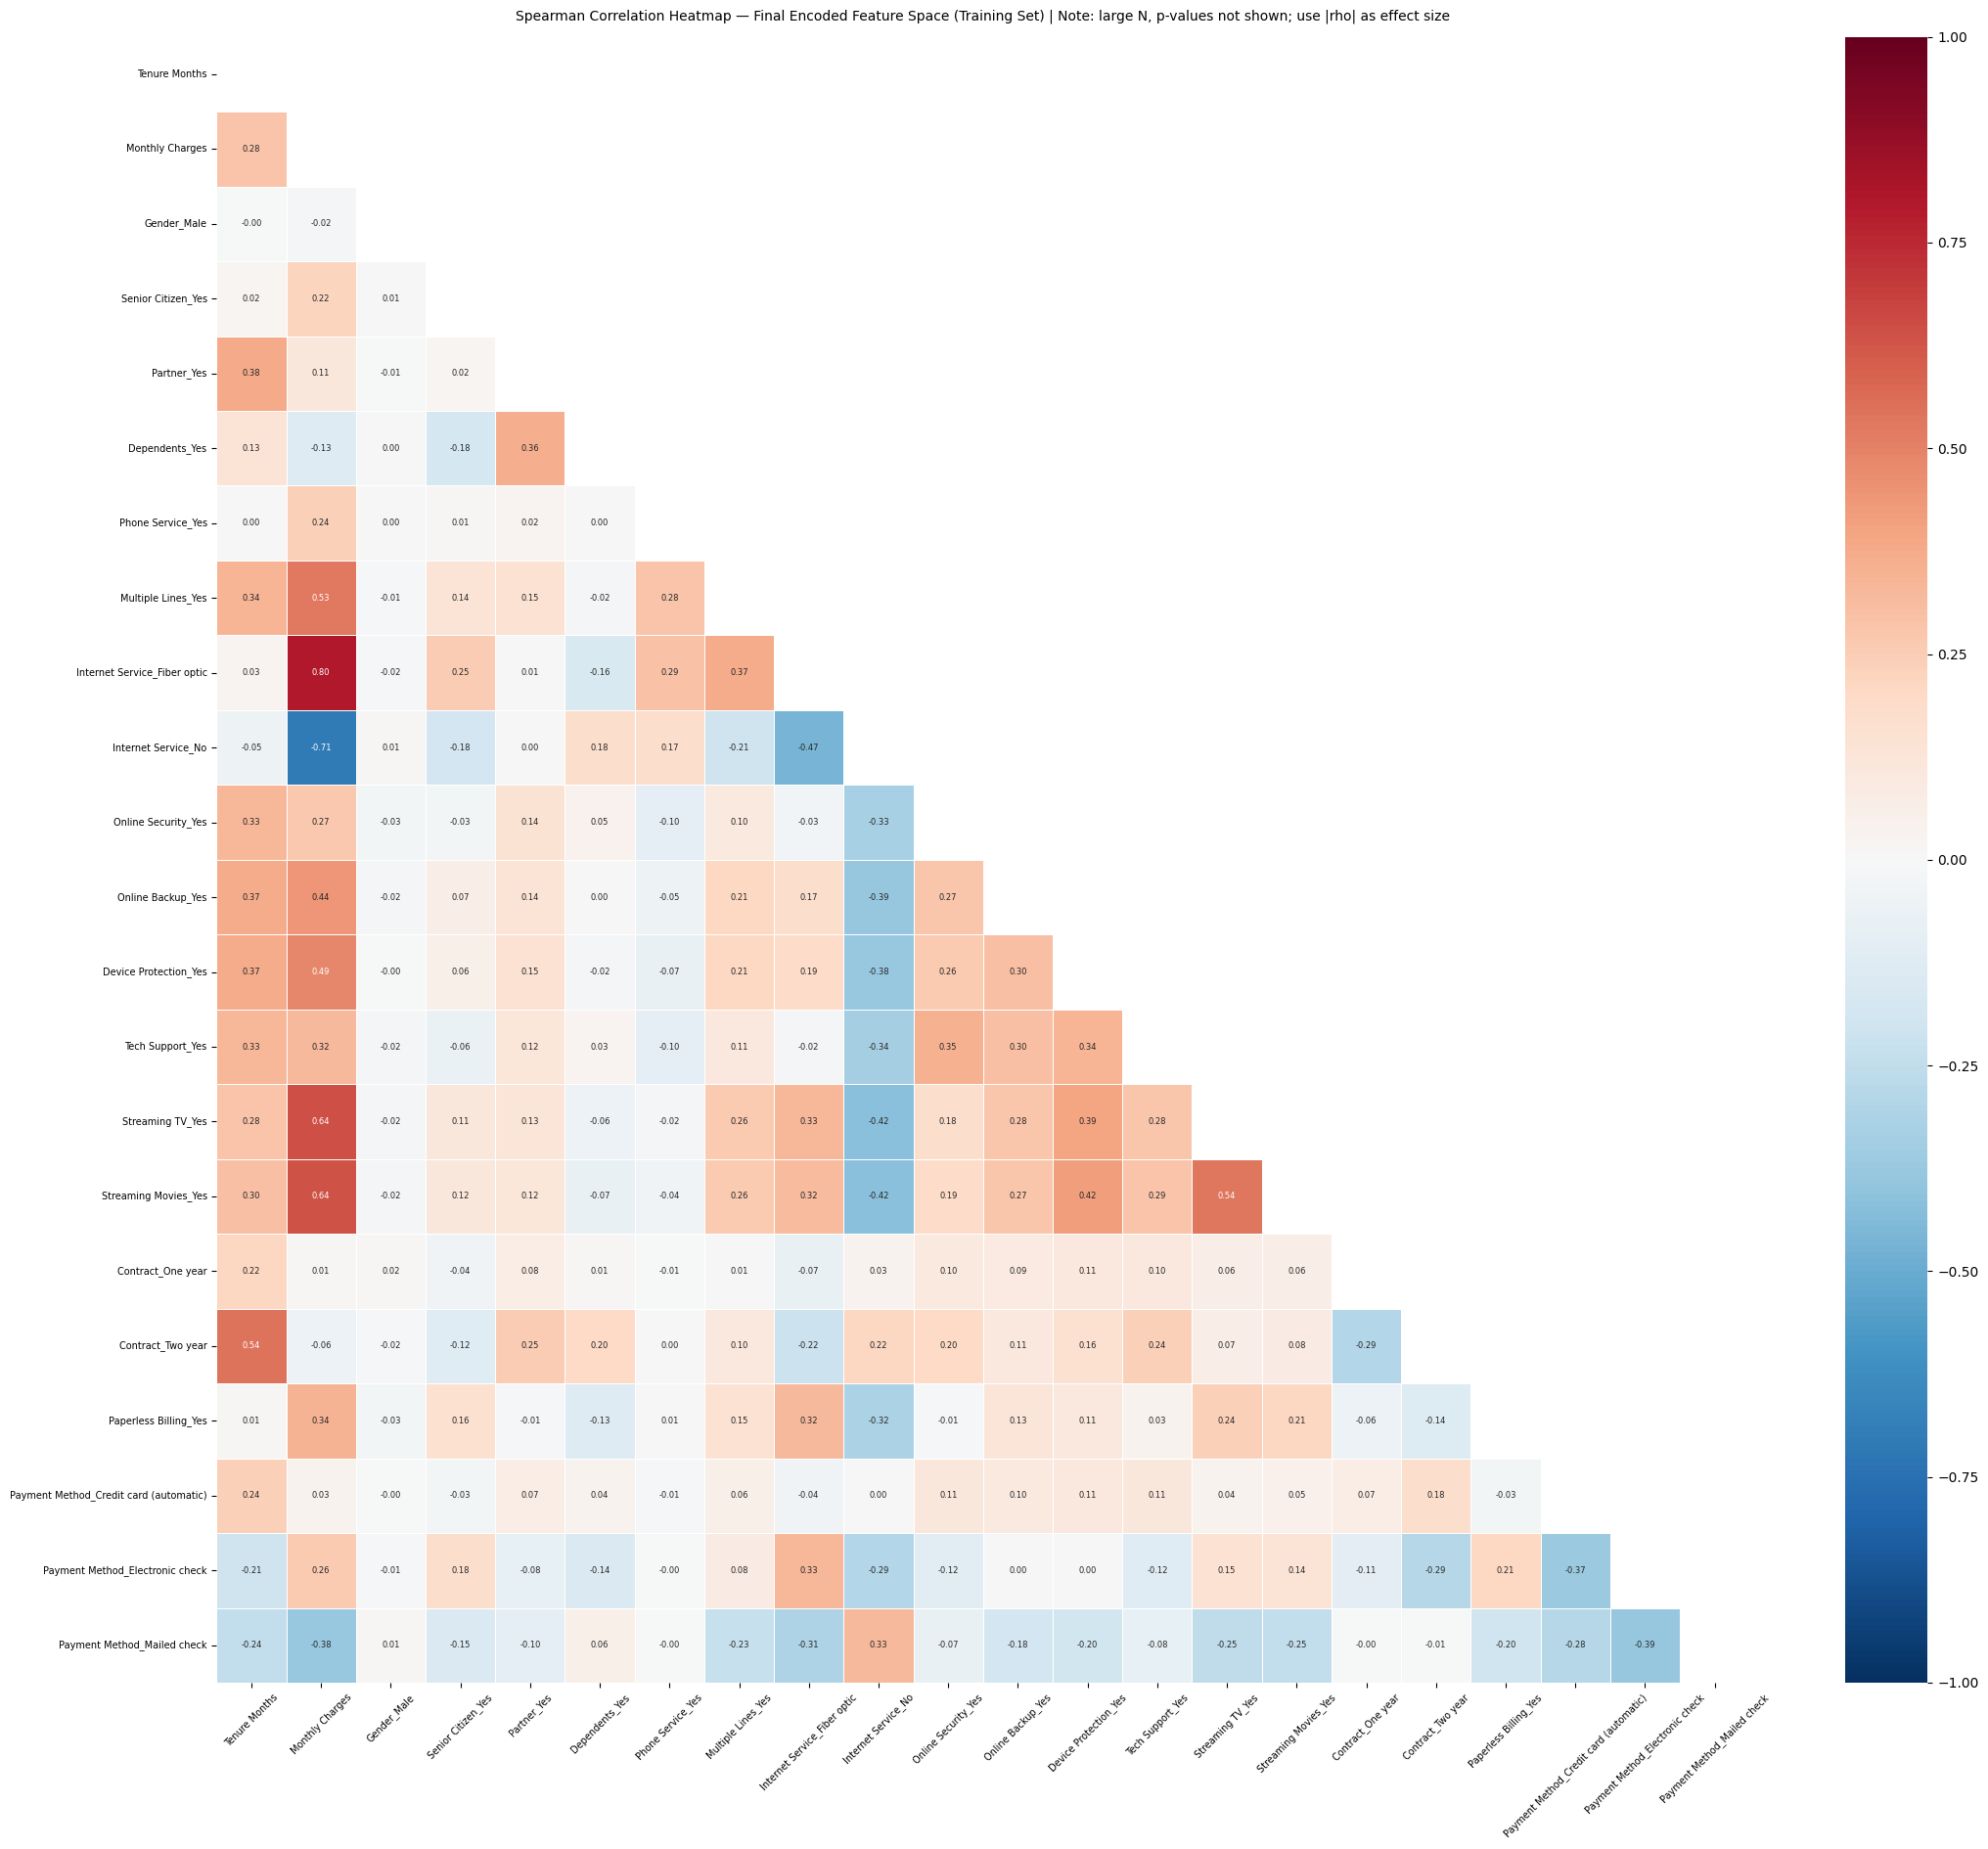

Strong   |rho| > 0.70  (2 pairs)
      Feature A                    Feature B  Spearman rho  |rho|
Monthly Charges Internet Service_Fiber optic        0.7990 0.7990
Monthly Charges          Internet Service_No       -0.7095 0.7095

Moderate |rho| 0.40-0.70  (11 pairs)
                   Feature A             Feature B  Spearman rho  |rho|
             Monthly Charges      Streaming TV_Yes        0.6447 0.6447
             Monthly Charges  Streaming Movies_Yes        0.6376 0.6376
               Tenure Months     Contract_Two year        0.5410 0.5410
            Streaming TV_Yes  Streaming Movies_Yes        0.5364 0.5364
             Monthly Charges    Multiple Lines_Yes        0.5261 0.5261
             Monthly Charges Device Protection_Yes        0.4893 0.4893
Internet Service_Fiber optic   Internet Service_No       -0.4652 0.4652
             Monthly Charges     Online Backup_Yes        0.4383 0.4383
         Internet Service_No  Streaming Movies_Yes       -0.4199 0.4199
         In

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# create the dataframe
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names_out)
print(f"X_train_processed_df shape: {X_train_processed_df.shape}")
print(f"Number of features: {len(feature_names_out)}")

# Spearman correlation matrix
corr_matrix = X_train_processed_df.corr(method="spearman")

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(22, 19))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor="white",
    annot_kws={"size": 6},
    ax=ax
)
ax.set_title(
    "Spearman Correlation Heatmap — Final Encoded Feature Space (Training Set)"
    " | Note: large N, p-values not shown; use |rho| as effect size",
    fontsize=10, pad=12
)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.show()

n = len(feature_names_out)
corr_pairs = []
for i in range(n):
    for j in range(i+1, n):
        rho = corr_matrix.iloc[i, j]
        corr_pairs.append({
            "Feature A":  feature_names_out[i],
            "Feature B":  feature_names_out[j],
            "Spearman rho": round(rho, 4),
            "|rho|":        round(abs(rho), 4),
        })

corr_df = pd.DataFrame(corr_pairs).sort_values("|rho|", ascending=False)

tiers = [("Strong   |rho| > 0.70", 0.70, 1.01),
          ("Moderate |rho| 0.40-0.70", 0.40, 0.70)]
for label, lo, hi in tiers:
    sub = corr_df[(corr_df["|rho|"] >= lo) & (corr_df["|rho|"] < hi)]
    print("=" * 60)
    print(f"{label}  ({len(sub)} pairs)")
    print("=" * 60)
    print(sub.to_string(index=False) if len(sub) else "  none")
    print()

high_corr_df = corr_df[corr_df["|rho|"] > 0.70].copy()

In [28]:
# Export processed_features.xlsx
# Input: X_train_processed_df
import os

print('=== Shape ===')
print(X_train_processed_df.shape)  

print('=== Missing value check ===')
missing = X_train_processed_df.isnull().sum().sum()
print(f'Total missing values: {missing}')  

print('=== Column consistency check ===')
print(f'Number of columns: {X_train_processed_df.shape[1]}, '
      f'Length of feature_names_out: {len(feature_names_out)}')

# Ensure column count matches feature names
assert X_train_processed_df.shape[1] == len(feature_names_out), \
    f'Column mismatch! DataFrame has {X_train_processed_df.shape[1]} columns, but feature_names_out has {len(feature_names_out)} features'

# Export to Excel 
output_path = os.path.join(os.getcwd(), 'processed_features.xlsx')
X_train_processed_df.to_excel(output_path, index=False)

print('=== Preview (first 5 rows) ===')
display(X_train_processed_df.head())

print(f'File saved to: {output_path}')

=== Shape ===
(5634, 22)
=== Missing value check ===
Total missing values: 0
=== Column consistency check ===
Number of columns: 22, Length of feature_names_out: 22
=== Preview (first 5 rows) ===


,Tenure Months,Monthly Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,...,Device Protection_Yes,Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,0.102371,-0.521976,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.711743,0.337478,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.793155,-0.809013,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.263980,0.284384,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
4,-1.281624,-0.676279,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


File saved to: d:\Personal\code\yyf\processed_features.xlsx


**3.3 VIF**

To assess multicollinearity among the predictors, the Variance Inflation Factor (VIF) was calculated for all numerical variables after excluding the target variables.

In [29]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

# --- Add intercept term (standard practice for VIF calculation) ---
X_vif_arr = sm.add_constant(X_train_processed_df).values.astype(float)

vif_rows = []

# --- Compute VIF for each feature ---
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # suppress warnings during VIF calculation
    for i, col in enumerate(X_train_processed_df.columns):
        try:
            v = variance_inflation_factor(X_vif_arr, i + 1)  # i+1 to skip intercept
        except Exception:
            v = float('nan')
        vif_rows.append({"Feature": col, "VIF": round(v, 2)})

# --- Create DataFrame and sort by VIF (descending) ---
vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False).reset_index(drop=True)

# --- Assign VIF risk levels ---
def vif_flag(v):
    if   v > 10:  return "⚠️ HIGH (>10)"
    elif v >  5:  return "⚡ MODERATE (5–10)"
    else:         return "✅ OK"

vif_df["Flag"] = vif_df["VIF"].apply(vif_flag)

# --- Display results ---
print("VIF — Final Encoded Feature Space (sorted descending)")
print("=" * 70)
print(vif_df.to_string(index=False))
print()

print(f"VIF > 10  (HIGH):     {(vif_df['VIF'] > 10).sum()} features")
print(f"VIF 5–10  (MODERATE): {((vif_df['VIF'] > 5) & (vif_df['VIF'] <= 10)).sum()} features")
print(f"VIF <= 5  (OK):       {(vif_df['VIF'] <= 5).sum()} features")

VIF — Final Encoded Feature Space (sorted descending)
                               Feature    VIF              Flag
                       Monthly Charges 860.35     ⚠️ HIGH (>10)
          Internet Service_Fiber optic 147.83     ⚠️ HIGH (>10)
                   Internet Service_No 103.11     ⚠️ HIGH (>10)
                     Phone Service_Yes  35.31     ⚠️ HIGH (>10)
                      Streaming TV_Yes  24.03     ⚠️ HIGH (>10)
                  Streaming Movies_Yes  24.02     ⚠️ HIGH (>10)
                    Multiple Lines_Yes   7.25 ⚡ MODERATE (5–10)
                 Device Protection_Yes   6.92 ⚡ MODERATE (5–10)
                     Online Backup_Yes   6.70 ⚡ MODERATE (5–10)
                      Tech Support_Yes   6.50 ⚡ MODERATE (5–10)
                   Online Security_Yes   6.35 ⚡ MODERATE (5–10)
                         Tenure Months   2.78              ✅ OK
                     Contract_Two year   2.62              ✅ OK
       Payment Method_Electronic check   1.97     

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Sort descending by VIF
vif_plot_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)

# Colour-code by risk level
def vif_color(v):
    if v > 10:  return '#d62728'   # red   -- high risk
    if v >= 5:  return '#ff7f0e'   # orange -- moderate
    return '#2ca02c'               # green  -- OK

colors = [vif_color(v) for v in vif_plot_df['VIF']]

fig, ax = plt.subplots(figsize=(16, 6))

bars = ax.bar(vif_plot_df['Feature'], vif_plot_df['VIF'],
              color=colors, edgecolor='white', linewidth=0.5)

# Reference threshold lines
ax.axhline(y=10, color='#d62728', linestyle='--', linewidth=1.2, label='VIF = 10 (high threshold)')
ax.axhline(y=5,  color='#ff7f0e', linestyle='--', linewidth=1.2, label='VIF = 5  (moderate threshold)')

# VIF value labels on top of each bar
for bar, val in zip(bars, vif_plot_df['VIF']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}',
            ha='center', va='bottom', fontsize=7, rotation=0)

# Axes and labels
ax.set_xlabel('Features', fontsize=11)
ax.set_ylabel('VIF Value', fontsize=11)
ax.set_title('VIF Distribution — Encoded Feature Space', fontsize=13, pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)

# Legend
legend_patches = [
    mpatches.Patch(color='#d62728', label='VIF > 10  (High risk)'),
    mpatches.Patch(color='#ff7f0e', label='5 <= VIF <= 10  (Moderate)'),
    mpatches.Patch(color='#2ca02c', label='VIF < 5  (OK)'),
]
ax.legend(handles=legend_patches + [
    plt.Line2D([0], [0], color='#d62728', linestyle='--', linewidth=1.2, label='VIF = 10 threshold'),
    plt.Line2D([0], [0], color='#ff7f0e', linestyle='--', linewidth=1.2, label='VIF = 5 threshold'),
], fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# Feature Selection Candidates — Based on Correlation + VIF Results
# ============================================================
import pandas as pd

print("=" * 70)
print("Feature selection candidate analysis (based on Heatmap + VIF)")
print("=" * 70)

# --- High-VIF candidates ---
high_vif = vif_df[vif_df["VIF"] > 10]["Feature"].tolist()
mod_vif  = vif_df[(vif_df["VIF"] > 5) & (vif_df["VIF"] <= 10)]["Feature"].tolist()

print("\n[VIF > 10: recommended for manual review]")
if high_vif:
    for f in high_vif:
        v = vif_df.loc[vif_df["Feature"] == f, "VIF"].values[0]
        # Check whether the feature comes from the same original variable's dummy encoding
        base = f.rsplit("_", 1)[0] if "_" in f else f
        note = f"(structural dummy, original feature '{base}')" if any(
            other.startswith(base + "_") for other in feature_names_out if other != f
        ) else "(cross-feature, potentially truly redundant)"
        print(f"  {f:45s}  VIF={v:.1f}  {note}")
else:
    print("  No features with VIF > 10")

print("\n[VIF 5-10: worth monitoring]")
if mod_vif:
    for f in mod_vif:
        v = vif_df.loc[vif_df["Feature"] == f, "VIF"].values[0]
        print(f"  {f:45s}  VIF={v:.1f}")
else:
    print("  No features with VIF between 5 and 10")

# --- Highly correlated candidates ---
print("\n[Highly correlated feature pairs (|r| > 0.80): recommended for manual review]")
try:
    if len(high_corr_df) > 0:
        for _, row in high_corr_df.iterrows():
            fa, fb, r = row["Feature A"], row["Feature B"], row["Spearman rho"]
            # Check whether both features come from the same original variable's dummy encoding
            base_a = fa.rsplit("_", 1)[0] if "_" in fa else fa
            base_b = fb.rsplit("_", 1)[0] if "_" in fb else fb
            same_origin = (base_a == base_b)
            note = "(same original variable dummy, structural correlation, usually safe to keep)" if same_origin else "⚠️ (cross-feature, worth further investigation)"
            print(f"  {fa:35s} ↔ {fb:35s}  r={r:+.3f}  {note}")
    else:
        print("  No highly correlated feature pairs")
except NameError:
    print("  (Please run Section 2.3.3 first to generate high_corr_df)")

print("\n" + "=" * 70)
print("[Recommendations]")
print("  1. High VIF / high correlation from the same original variable's dummy encoding -> structural effect, safe to keep")
print("  2. High correlation across different original features -> consider as candidates for removal in later modeling")
print("  3. At this stage: mark as candidates only; do not remove automatically")
print("  4. After manual review, decide whether to remove them from num_features / cat_features")
print("=" * 70)

Feature selection candidate analysis (based on Heatmap + VIF)

[VIF > 10: recommended for manual review]
  Monthly Charges                                VIF=860.4  (cross-feature, potentially truly redundant)
  Internet Service_Fiber optic                   VIF=147.8  (structural dummy, original feature 'Internet Service')
  Internet Service_No                            VIF=103.1  (structural dummy, original feature 'Internet Service')
  Phone Service_Yes                              VIF=35.3  (cross-feature, potentially truly redundant)
  Streaming TV_Yes                               VIF=24.0  (cross-feature, potentially truly redundant)
  Streaming Movies_Yes                           VIF=24.0  (cross-feature, potentially truly redundant)

[VIF 5-10: worth monitoring]
  Multiple Lines_Yes                             VIF=7.2
  Device Protection_Yes                          VIF=6.9
  Online Backup_Yes                              VIF=6.7
  Tech Support_Yes                           

## 3.4 Feature Importance and Feature Reduction

Before evaluating any predictive model, we run permutation importance using an **auxiliary tree-based estimator** trained on the full cleaned feature set. A tree ensemble is chosen as the auxiliary estimator because it handles mixed feature types (numerical and categorical) natively and provides both MDI and permutation importance out of the box. Crucially, permutation importance is measured on the held-out **test set**, so the scores reflect generalisation ability rather than the fitting behaviour of any specific model architecture.

This step is model-independent: the resulting importance scores are not re-used inside any of the three model chapters — they serve solely as a shared feature-selection criterion.

The analysis produces two standardised feature sets that every downstream model will use:

| Dataset | Description | Variables |
|---|---|---|
| **Full** | All 18 cleaned features | `X_train_raw` / `X_test_raw` |
| **Reduced** | Top-4 by permutation importance | `X_train_top4` / `X_test_top4` |

Running each model on **both** sets answers two complementary questions:
1. Which model architecture performs best given the same information?
2. How sensitive is each model to feature reduction?

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Auxiliary estimator: tree ensemble fitted on the full feature set
# Used only for importance extraction -- not reused in Section 4
aux_estimator = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])
aux_estimator.fit(X_train_raw, y_train)

prep_step = aux_estimator.named_steps['preprocessor']
feature_names_post = prep_step.get_feature_names_out().tolist()
feature_names_raw  = X_train_raw.columns.tolist()

# 1. MDI importance (reference only, post-preprocessing space)
mdi_df = pd.DataFrame({
    "Feature": feature_names_post,
    "MDI":     aux_estimator.named_steps["classifier"].feature_importances_
}).sort_values('MDI', ascending=False).reset_index(drop=True)

print('=== MDI Feature Importance (Top 15, reference only) ===')
print(mdi_df.head(15).to_string(index=False))

# 2. Permutation Importance (primary metric, raw feature space, test set)
perm_result = permutation_importance(
    aux_estimator, X_test_raw, y_test,
    n_repeats=30, scoring='roc_auc', random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature":   feature_names_raw,
    "Perm_Mean": perm_result.importances_mean,
    "Perm_Std":  perm_result.importances_std
}).sort_values('Perm_Mean', ascending=False).reset_index(drop=True)

print('=== Permutation Importance (all features, ranked) ===')
print(perm_df.to_string(index=False))

# Side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=mdi_df.head(15), x='MDI', y='Feature', palette='magma', ax=axes[0])
axes[0].set_title('MDI Importance(post-preprocessing, reference only)')

top15_perm = perm_df.head(15).copy()
sns.barplot(data=top15_perm, x='Perm_Mean', y='Feature', palette='viridis', ax=axes[1])
for i, row in enumerate(top15_perm.itertuples()):
    axes[1].errorbar(x=row.Perm_Mean, y=i, xerr=row.Perm_Std,
                     fmt='none', ecolor='black', capsize=3)
axes[1].set_title('Permutation Importance(raw features, primary metric)')

plt.suptitle('Feature Importance -- Auxiliary Estimator (Full Feature Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 41) (1524750583.py, line 41)

**Interpretation: MDI vs Permutation Importance**

**MDI (Mean Decrease in Impurity)** accumulates impurity reduction across all trees in the forest. Because continuous features such as *Tenure Months* and *Monthly Charges* offer many candidate split thresholds, they systematically receive higher MDI scores regardless of true predictive value. MDI is retained here as a reference but should not drive feature selection.

**Permutation Importance** measures the drop in ROC-AUC when each raw feature's values are randomly shuffled on the held-out test set, breaking its relationship with the target. This approach is agnostic to feature type and scale, giving a fair comparison between numerical variables and one-hot-encoded categorical ones. The **top-4 features by permutation importance** are selected as the reduced feature set shared by all three downstream models.

In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Reduced feature set: top-4 by permutation importance
top4_features = perm_df.head(4)['Feature'].tolist()
print('Full feature set    :', X_train_raw.columns.tolist())
print('Reduced feature set :', top4_features)

X_train_top4 = X_train_raw[top4_features].copy()
X_test_top4  = X_test_raw[top4_features].copy()

# Preprocessor for the reduced feature set (same strategy as the full preprocessor)
num_top4 = [f for f in top4_features if X_train_raw[f].dtype != object]
cat_top4 = [f for f in top4_features if X_train_raw[f].dtype == object]

transformers_top4 = []
if num_top4:
    transformers_top4.append((
        'num',
        Pipeline([('impute', SimpleImputer(strategy='median')),
                  ('scale',  StandardScaler())]),
        num_top4
    ))
if cat_top4:
    transformers_top4.append((
        'cat',
        Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                  ('ohe',   OneHotEncoder(handle_unknown='ignore', drop='first',
                                          sparse_output=False))]),
        cat_top4
    ))

preprocessor_top4 = ColumnTransformer(transformers=transformers_top4, remainder='drop')

print(f'\nX_train_raw  shape : {X_train_raw.shape}   (full, {len(X_train_raw.columns)} features)')
print(f'X_train_top4 shape : {X_train_top4.shape}  (reduced, {len(top4_features)} features)')
print(f'preprocessor       : full ColumnTransformer ({len(num_features)} num + {len(cat_features)} cat)')
print(f'preprocessor_top4  : reduced ColumnTransformer ({len(num_top4)} num + {len(cat_top4)} cat)')

NameError: name 'perm_df' is not defined

## 4. Model Selection

Three classification models are evaluated and compared: Logistic Regression, Random Forest, and XGBoost. Each model is run on **two standardised feature sets** defined in Section 3.4:

- **Full feature set**: all 18 cleaned customer attributes (`X_train_raw` / `X_test_raw`)
- **Reduced feature set**: the top-4 permutation-important features (`X_train_top4` / `X_test_top4`)

This dual-feature design enables two distinct comparisons:
1. **Same feature set, different models**: which architecture best exploits the available information?
2. **Same model, different feature sets**: how much does each model benefit from or suffer under feature reduction?

Results from all six experiments are consolidated in Section 4.4.

**Cross-validation protocol:** Ten-fold stratified cross-validation is used throughout. With approximately 7,000 observations, each fold retains 90% of the training data, providing a low-bias estimate of generalisation performance at a fraction of the computational cost of leave-one-out CV (Kohavi, 1995).

**4.1 Logistic Regression**

Logistic Regression models churn probability as a sigmoid-transformed linear combination of input features, providing an interpretable linear baseline for binary classification.

**Experimental setup (both runs):**
- **Preprocessing**: unified `ColumnTransformer` — median imputation + StandardScaler for numerical; mode imputation + OneHotEncoder(drop='first') for categorical; re-fitted inside every CV fold
- **Evaluation**: 10-fold stratified cross-validation on the training set, then test-set evaluation
- **Target**: `Churn Value` (0 = retained, 1 = churned)

**4.1.A — Full Feature Set**

Input: `X_train_raw` / `X_test_raw` (18 features) with the full `preprocessor`.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

lr_full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_lr_full = cross_validate(
    lr_full_pipeline, X_train_raw, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
lr_full_cv_df = pd.DataFrame({
    'Metric':     metrics,
    'Train Mean': [round(cv_scores_lr_full[f'train_{m}'].mean(), 4) for m in metrics],
    'Val Mean':   [round(cv_scores_lr_full[f'test_{m}'].mean(),  4) for m in metrics],
    'Val Std':    [round(cv_scores_lr_full[f'test_{m}'].std(),   4) for m in metrics],
})
print('=== LR (Full) -- 10-Fold CV ===')
print(lr_full_cv_df.to_string(index=False))

lr_full_pipeline.fit(X_train_raw, y_train)
y_pred_lr_full  = lr_full_pipeline.predict(X_test_raw)
y_proba_lr_full = lr_full_pipeline.predict_proba(X_test_raw)[:, 1]

lr_full_results = {
    'Accuracy':  accuracy_score(y_test, y_pred_lr_full),
    'Precision': precision_score(y_test, y_pred_lr_full),
    'Recall':    recall_score(y_test, y_pred_lr_full),
    'F1':        f1_score(y_test, y_pred_lr_full),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_lr_full),
}
print('\n=== LR (Full) -- Test Set Results ===')
for k, v in lr_full_results.items():
    print(f'  {k:<12}: {v:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_lr_full, target_names=['Not Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr_full, display_labels=['Not Churn', 'Churn'], cmap='Blues', ax=ax
)
ax.set_title('LR (Full Features) -- Confusion Matrix')
plt.tight_layout()
plt.show()

**4.1.B — Reduced Feature Set (Top-4)**

Input: `X_train_top4` / `X_test_top4` with `preprocessor_top4`.

In [ ]:
lr_reduced_pipeline = Pipeline([
    ('preprocessor', preprocessor_top4),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_lr_reduced = cross_validate(
    lr_reduced_pipeline, X_train_top4, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
lr_reduced_cv_df = pd.DataFrame({
    'Metric':     metrics,
    'Train Mean': [round(cv_scores_lr_reduced[f'train_{m}'].mean(), 4) for m in metrics],
    'Val Mean':   [round(cv_scores_lr_reduced[f'test_{m}'].mean(),  4) for m in metrics],
    'Val Std':    [round(cv_scores_lr_reduced[f'test_{m}'].std(),   4) for m in metrics],
})
print('=== LR (Reduced) -- 10-Fold CV ===')
print(lr_reduced_cv_df.to_string(index=False))

lr_reduced_pipeline.fit(X_train_top4, y_train)
y_pred_lr_reduced  = lr_reduced_pipeline.predict(X_test_top4)
y_proba_lr_reduced = lr_reduced_pipeline.predict_proba(X_test_top4)[:, 1]

lr_reduced_results = {
    'Accuracy':  accuracy_score(y_test, y_pred_lr_reduced),
    'Precision': precision_score(y_test, y_pred_lr_reduced),
    'Recall':    recall_score(y_test, y_pred_lr_reduced),
    'F1':        f1_score(y_test, y_pred_lr_reduced),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_lr_reduced),
}
print('\n=== LR (Reduced) -- Test Set Results ===')
for k, v in lr_reduced_results.items():
    print(f'  {k:<12}: {v:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_lr_reduced, target_names=['Not Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr_reduced, display_labels=['Not Churn', 'Churn'], cmap='Blues', ax=ax
)
ax.set_title('LR (Reduced, Top-4) -- Confusion Matrix')
plt.tight_layout()
plt.show()

**4.2 Random Forest**

Random Forest builds an ensemble of decision trees via bagging and random feature subsampling, reducing variance and capturing non-linear interactions beyond Logistic Regression's linear boundary.

**Experimental setup (both runs):**
- **Preprocessing**: same `ColumnTransformer` strategy, re-fitted inside every CV fold
- **Step 1**: Baseline model (`max_depth=None`) — 10-fold stratified CV to quantify overfitting
- **Step 2**: `RandomizedSearchCV` (50 iterations, 5-fold CV, ROC-AUC) for regularisation
- **Step 3**: Final tuned model evaluated on the held-out test set

**4.2.A — Full Feature Set**

Input: `X_train_raw` / `X_test_raw` (18 features) with the full `preprocessor`.

**Step 1: Baseline Model and Overfitting Assessment**

An unconstrained Random Forest (`max_depth=None`) is assessed via 10-fold stratified CV. The train/validation accuracy gap reveals the degree of overfitting on the full feature set.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt

rf_full_baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=None, random_state=42, n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_rf_full = cross_validate(
    rf_full_baseline, X_train_raw, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
rf_full_cv_df = pd.DataFrame({
    'Metric':     metrics,
    'Train Mean': [round(cv_scores_rf_full[f'train_{m}'].mean(), 4) for m in metrics],
    'Val Mean':   [round(cv_scores_rf_full[f'test_{m}'].mean(),  4) for m in metrics],
    'Val Std':    [round(cv_scores_rf_full[f'test_{m}'].std(),   4) for m in metrics],
})
print('=== RF (Full) Baseline -- 10-Fold CV ===')
print(rf_full_cv_df.to_string(index=False))
train_acc = cv_scores_rf_full['train_accuracy'].mean()
val_acc   = cv_scores_rf_full['test_accuracy'].mean()
print(f'\nTrain-Val Accuracy Gap: {train_acc - val_acc:.4f}  '
      f'(Train {train_acc:.4f} vs Val {val_acc:.4f})')

**Step 2: Hyperparameter Tuning with RandomizedSearchCV**

`RandomizedSearchCV` is applied over `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, and `n_estimators`. 50 random configurations, 5-fold CV, ROC-AUC objective.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'classifier__n_estimators':      [100, 200, 300],
    'classifier__max_depth':         [5, 8, 10, 12, 15],
    'classifier__min_samples_split': [5, 10, 20],
    'classifier__min_samples_leaf':  [2, 5, 10],
    'classifier__max_features':      ['sqrt', 'log2']
}

rf_full_tune_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

random_search_rf_full = RandomizedSearchCV(
    estimator=rf_full_tune_pipeline,
    param_distributions=param_dist_rf,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=1
)

random_search_rf_full.fit(X_train_raw, y_train)
print('Best Parameters:', random_search_rf_full.best_params_)
print(f'Best CV ROC-AUC: {random_search_rf_full.best_score_:.4f}')

**Step 3: Final Model Evaluation on Test Set**

In [ ]:
best_rf_full = random_search_rf_full.best_estimator_

y_pred_rf_full  = best_rf_full.predict(X_test_raw)
y_proba_rf_full = best_rf_full.predict_proba(X_test_raw)[:, 1]

rf_full_results = {
    'Accuracy':  accuracy_score(y_test, y_pred_rf_full),
    'Precision': precision_score(y_test, y_pred_rf_full),
    'Recall':    recall_score(y_test, y_pred_rf_full),
    'F1':        f1_score(y_test, y_pred_rf_full),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_rf_full),
}
print('=== RF (Full, Tuned) -- Test Set Results ===')
for k, v in rf_full_results.items():
    print(f'  {k:<12}: {v:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_rf_full, target_names=['Not Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf_full, display_labels=['Not Churn', 'Churn'], cmap='Blues', ax=ax
)
ax.set_title('RF (Full Features, Tuned) -- Confusion Matrix')
plt.tight_layout()
plt.show()

**4.2.B — Reduced Feature Set (Top-4)**

Same three-step procedure applied to `X_train_top4` / `X_test_top4` with `preprocessor_top4`. Steps 1-3 are consolidated into a single cell since the methodology is identical to 4.2.A.

In [ ]:
# Step 1: Baseline CV
rf_reduced_baseline = Pipeline([
    ('preprocessor', preprocessor_top4),
    ('classifier', RandomForestClassifier(
        n_estimators=200, max_depth=None, random_state=42, n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_rf_reduced = cross_validate(
    rf_reduced_baseline, X_train_top4, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
rf_reduced_cv_df = pd.DataFrame({
    'Metric':     metrics,
    'Train Mean': [round(cv_scores_rf_reduced[f'train_{m}'].mean(), 4) for m in metrics],
    'Val Mean':   [round(cv_scores_rf_reduced[f'test_{m}'].mean(),  4) for m in metrics],
    'Val Std':    [round(cv_scores_rf_reduced[f'test_{m}'].std(),   4) for m in metrics],
})
print('=== RF (Reduced) Baseline -- 10-Fold CV ===')
print(rf_reduced_cv_df.to_string(index=False))
train_acc = cv_scores_rf_reduced['train_accuracy'].mean()
val_acc   = cv_scores_rf_reduced['test_accuracy'].mean()
print(f'\nTrain-Val Accuracy Gap: {train_acc - val_acc:.4f}')

# Step 2: Tuning
rf_reduced_tune_pipeline = Pipeline([
    ('preprocessor', preprocessor_top4),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

random_search_rf_reduced = RandomizedSearchCV(
    estimator=rf_reduced_tune_pipeline,
    param_distributions=param_dist_rf,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=1
)

random_search_rf_reduced.fit(X_train_top4, y_train)
print('\nBest Parameters:', random_search_rf_reduced.best_params_)
print(f'Best CV ROC-AUC: {random_search_rf_reduced.best_score_:.4f}')

# Step 3: Test Set Evaluation
best_rf_reduced = random_search_rf_reduced.best_estimator_

y_pred_rf_reduced  = best_rf_reduced.predict(X_test_top4)
y_proba_rf_reduced = best_rf_reduced.predict_proba(X_test_top4)[:, 1]

rf_reduced_results = {
    'Accuracy':  accuracy_score(y_test, y_pred_rf_reduced),
    'Precision': precision_score(y_test, y_pred_rf_reduced),
    'Recall':    recall_score(y_test, y_pred_rf_reduced),
    'F1':        f1_score(y_test, y_pred_rf_reduced),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_rf_reduced),
}
print('\n=== RF (Reduced, Tuned) -- Test Set Results ===')
for k, v in rf_reduced_results.items():
    print(f'  {k:<12}: {v:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_rf_reduced, target_names=['Not Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf_reduced, display_labels=['Not Churn', 'Churn'], cmap='Blues', ax=ax
)
ax.set_title('RF (Reduced, Top-4, Tuned) -- Confusion Matrix')
plt.tight_layout()
plt.show()

**4.3 XGBoost**

XGBoost (Extreme Gradient Boosting) constructs trees sequentially, with each tree correcting the residual errors of its predecessors. Unlike the parallel bagging in Random Forest, boosting focuses modelling capacity on hard-to-classify observations, often yielding superior performance. L1/L2 regularisation parameters (`reg_alpha`, `reg_lambda`) and subsampling ratios control overfitting.

**Experimental setup (both runs):**
- **Preprocessing**: same `ColumnTransformer` strategy wrapped in `Pipeline`, re-fitted inside each CV fold
- **Step 1**: Baseline 10-fold stratified CV
- **Step 2**: `RandomizedSearchCV` (50 iterations, 5-fold CV, ROC-AUC)
- **Step 3**: Final evaluation on the held-out test set

**4.3.A — Full Feature Set**

Input: `X_train_raw` / `X_test_raw` (18 features) with the full `preprocessor`.

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Baseline CV
xgb_full_baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss', n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_xgb_full = cross_validate(
    xgb_full_baseline, X_train_raw, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
xgb_full_cv_df = pd.DataFrame({
    'Metric':     metrics,
    'Train Mean': [round(cv_scores_xgb_full[f'train_{m}'].mean(), 4) for m in metrics],
    'Val Mean':   [round(cv_scores_xgb_full[f'test_{m}'].mean(),  4) for m in metrics],
    'Val Std':    [round(cv_scores_xgb_full[f'test_{m}'].std(),   4) for m in metrics],
})
print('=== XGBoost (Full) Baseline -- 10-Fold CV ===')
print(xgb_full_cv_df.to_string(index=False))

# Step 2: Tuning
param_dist_xgb = {
    'classifier__n_estimators':     [100, 200, 300],
    'classifier__max_depth':        [3, 5, 7],
    'classifier__learning_rate':    [0.01, 0.05, 0.1],
    'classifier__subsample':        [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0],
    'classifier__reg_alpha':        [0, 0.1, 0.5],
    'classifier__reg_lambda':       [1.0, 1.5, 2.0],
}

xgb_full_tune_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1))
])

random_search_xgb_full = RandomizedSearchCV(
    estimator=xgb_full_tune_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=1
)

random_search_xgb_full.fit(X_train_raw, y_train)
print('Best Parameters:', random_search_xgb_full.best_params_)
print(f'Best CV ROC-AUC: {random_search_xgb_full.best_score_:.4f}')

# Step 3: Test Set Evaluation
best_xgb_full = random_search_xgb_full.best_estimator_

y_pred_xgb_full  = best_xgb_full.predict(X_test_raw)
y_proba_xgb_full = best_xgb_full.predict_proba(X_test_raw)[:, 1]

xgb_full_results = {
    'Accuracy':  accuracy_score(y_test, y_pred_xgb_full),
    'Precision': precision_score(y_test, y_pred_xgb_full),
    'Recall':    recall_score(y_test, y_pred_xgb_full),
    'F1':        f1_score(y_test, y_pred_xgb_full),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_xgb_full),
}
print('\n=== XGBoost (Full, Tuned) -- Test Set Results ===')
for k, v in xgb_full_results.items():
    print(f'  {k:<12}: {v:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_xgb_full, target_names=['Not Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_full, display_labels=['Not Churn', 'Churn'], cmap='Blues', ax=ax
)
ax.set_title('XGBoost (Full Features, Tuned) -- Confusion Matrix')
plt.tight_layout()
plt.show()

**4.3.B — Reduced Feature Set (Top-4)**

Input: `X_train_top4` / `X_test_top4` with `preprocessor_top4`.

In [ ]:
# Step 1: Baseline CV
xgb_reduced_baseline = Pipeline([
    ('preprocessor', preprocessor_top4),
    ('classifier', XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss', n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_xgb_reduced = cross_validate(
    xgb_reduced_baseline, X_train_top4, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True
)

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
xgb_reduced_cv_df = pd.DataFrame({
    'Metric':     metrics,
    'Train Mean': [round(cv_scores_xgb_reduced[f'train_{m}'].mean(), 4) for m in metrics],
    'Val Mean':   [round(cv_scores_xgb_reduced[f'test_{m}'].mean(),  4) for m in metrics],
    'Val Std':    [round(cv_scores_xgb_reduced[f'test_{m}'].std(),   4) for m in metrics],
})
print('=== XGBoost (Reduced) Baseline -- 10-Fold CV ===')
print(xgb_reduced_cv_df.to_string(index=False))

# Step 2: Tuning
xgb_reduced_tune_pipeline = Pipeline([
    ('preprocessor', preprocessor_top4),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1))
])

random_search_xgb_reduced = RandomizedSearchCV(
    estimator=xgb_reduced_tune_pipeline,
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=1
)

random_search_xgb_reduced.fit(X_train_top4, y_train)
print('Best Parameters:', random_search_xgb_reduced.best_params_)
print(f'Best CV ROC-AUC: {random_search_xgb_reduced.best_score_:.4f}')

# Step 3: Test Set Evaluation
best_xgb_reduced = random_search_xgb_reduced.best_estimator_

y_pred_xgb_reduced  = best_xgb_reduced.predict(X_test_top4)
y_proba_xgb_reduced = best_xgb_reduced.predict_proba(X_test_top4)[:, 1]

xgb_reduced_results = {
    'Accuracy':  accuracy_score(y_test, y_pred_xgb_reduced),
    'Precision': precision_score(y_test, y_pred_xgb_reduced),
    'Recall':    recall_score(y_test, y_pred_xgb_reduced),
    'F1':        f1_score(y_test, y_pred_xgb_reduced),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_xgb_reduced),
}
print('\n=== XGBoost (Reduced, Tuned) -- Test Set Results ===')
for k, v in xgb_reduced_results.items():
    print(f'  {k:<12}: {v:.4f}')

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_xgb_reduced, target_names=['Not Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_reduced, display_labels=['Not Churn', 'Churn'], cmap='Blues', ax=ax
)
ax.set_title('XGBoost (Reduced, Top-4, Tuned) -- Confusion Matrix')
plt.tight_layout()
plt.show()

## 4.4 Model Comparison Summary

The table below consolidates test-set results from all six experiments. Reading **across rows** compares full vs reduced feature sets within the same model — revealing each model's sensitivity to feature reduction. Reading **down columns** compares model architectures on an identical feature set.

In [ ]:
import pandas as pd

comparison_rows = [
    {'Model': 'Logistic Regression', 'Feature Set': 'Full (18)',       **lr_full_results},
    {'Model': 'Logistic Regression', 'Feature Set': 'Reduced (top-4)', **lr_reduced_results},
    {'Model': 'Random Forest',       'Feature Set': 'Full (18)',       **rf_full_results},
    {'Model': 'Random Forest',       'Feature Set': 'Reduced (top-4)', **rf_reduced_results},
    {'Model': 'XGBoost',             'Feature Set': 'Full (18)',       **xgb_full_results},
    {'Model': 'XGBoost',             'Feature Set': 'Reduced (top-4)', **xgb_reduced_results},
]

comparison_df = pd.DataFrame(comparison_rows)
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    comparison_df[col] = comparison_df[col].round(4)

print('=== Model Comparison -- Test Set Results (all 6 experiments) ===')
print(comparison_df.to_string(index=False))

## 4.5 ROC Curve Comparison

ROC curves visualise the trade-off between True Positive Rate (sensitivity) and False Positive Rate across all classification thresholds. Plotting **Full vs Reduced** on the same axes for each model makes the cost of feature reduction immediately visible. A combined panel (Section 4.5.B) then places all three Full-feature curves side by side for cross-model comparison.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_comparison(y_test, y_prob_full, y_prob_reduced, model_name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
        standalone = True
    else:
        standalone = False

    for y_prob, label, color in [
        (y_prob_full,    'Full',    '#1f77b4'),
        (y_prob_reduced, 'Reduced', '#ff7f0e'),
    ]:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{model_name} ({label})  AUC = {auc:.3f}')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random guess')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {model_name}')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

    if standalone:
        plt.tight_layout()
        plt.show()

# ── 4.5.A: Per-model Full vs Reduced ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_roc_comparison(y_test, y_proba_lr_full,  y_proba_lr_reduced,  'Logistic Regression', ax=axes[0])
plot_roc_comparison(y_test, y_proba_rf_full,  y_proba_rf_reduced,  'Random Forest',       ax=axes[1])
plot_roc_comparison(y_test, y_proba_xgb_full, y_proba_xgb_reduced, 'XGBoost',             ax=axes[2])

plt.suptitle('ROC Curves: Full vs Reduced Feature Set (per model)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── 4.5.B: Cross-model comparison on Full feature set ─────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

for y_prob, name, color in [
    (y_proba_lr_full,  'Logistic Regression', '#1f77b4'),
    (y_proba_rf_full,  'Random Forest',       '#2ca02c'),
    (y_proba_xgb_full, 'XGBoost',             '#d62728'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  AUC = {auc:.3f}')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — All Models (Full Feature Set)')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

## 5. Q&A

**Q: For the high churn rate among month-to-month users, what do you think would be the most effective intervention strategy?**

A: The most effective strategy is to increase their switching costs by offering discounts or bundled services to incentivize signing a one-year contract. Crucially, we will use our model to cross-reference Churn Score and CLTV, ensuring we only target these retention efforts toward high-risk, high-value customers.

**Q: If the prediction model has high accuracy but low recall, how would that impact customer retention efforts and how would you address it?**

A: High accuracy with low recall means the model misses many actual churners, causing the company to lose revenue because these at-risk customers slip away without receiving any retention offers. To address this, we would lower the prediction threshold to capture more potential churners, apply class weights to heavily penalize false negatives.

**Q: Considering that customer behavior evolves over time, did you look into the issue of 'Concept Drift'? How often would you recommend retraining the model to maintain its predictive accuracy in a changing market?**

A: To ensure the model adapts to evolving customer behaviors and market conditions, we recommend a dual approach: scheduling regular model retraining on a quarterly basis using the latest data, and implementing continuous monitoring of key metrics like recall and precision to automatically trigger an immediate retraining cycle if performance drops below a predefined acceptable threshold.

**Q: Once all work is complete, what level of performance does your team anticipate achieving? Furthermore, I would be very interested to learn what commonalities exist between your model and the current state-of-the-art models.**

A: We anticipate achieving an ROC-AUC score above 0.85 and a highly optimized recall rate to ensure we capture the vast majority of at-risk customers.

**Q: Which factors were the most important for predicting churn?**

A: Based on our analysis, the most critical factors for predicting churn are contract terms, customer longevity, and financial metrics. Contract Type is the strongest predictor, with month-to-month users showing the highest churn risk. Tenure Months is also heavily weighted, as newer customers are far more likely to leave than long-term veterans. Additionally, high Monthly Charges, particularly when interacting with specific services like Fiber Optic internet, strongly signal churn risk, making these three features the core drivers of our predictive model.

**Q: Will the handling of missing values and in the preprocessing stage affect the performance and bias of the model?**

A: Yes, absolutely. How you handle missing values directly impacts both performance and bias.

**Q: What is the target of Hyperparameter Optimization?**

A: The primary target of hyperparameter optimization is to find the optimal combination of model settings (which are not learned from the data itself) to maximize the model's performance on unseen data.

**Q: Is your dataset imbalanced?**

A: Yes, the dataset is inherently imbalanced, which is typical for real-world scenarios where the majority of customers stay and only a smaller percentage actually churn.

**Q: From the plots across different features, it is difficult to identify clear relationships with churn. Could you elaborate on how the data preprocessing and cleaning steps could be improved to better reveal these patterns?**

A: That is a great observation. The lack of clear linear patterns in the raw data highlights the absolute necessity of advanced feature engineering.